# Task-ID Ablation Results Notebook

Run inside `custom-mt-pairs-no-id/`. Compares no-task-ID pair results.


In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

ROOT = Path(".")
print("Working directory:", ROOT.resolve())


Working directory: C:\Users\Michalis\Documents\GitHub\Metaworld-Tests\custom-mt-pairs-no-id


## 1. Load results


In [2]:

summary_files = [p for p in ROOT.rglob("*_summary.csv") if "skipped" not in p.name.lower() and "checkpoint" not in p.name.lower()]
dfs = []
for p in summary_files:
    try:
        df = pd.read_csv(p)
        if {"config", "task_name", "success_rate"}.issubset(df.columns):
            exp = p.name.replace("_summary.csv", "")
            df["experiment"] = exp
            df["source_file"] = str(p)
            dfs.append(df)
    except Exception as e:
        print("Could not read", p, e)

data = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
print("Summary files:")
for p in summary_files:
    print(" -", p)
print("Loaded rows:", len(data))
display(data.head())


Summary files:
 - basketball_pickplace_noid_eval_results\basketball_pickplace_noid_summary.csv
 - basketball_push_noid_eval_results\basketball_push_noid_summary.csv
 - button_push_noid_eval_results\button_push_noid_summary.csv
 - push_pickplace_noid_eval_results\push_pickplace_noid_summary.csv
Loaded rows: 8


,config,task_name,success_rate,avg_return,std_return,avg_episode_length,std_episode_length,avg_first_success_step,median_first_success_step,episodes,experiment,source_file
0,careful,basketball-v3,1.0,122.139437,11.757968,53.800000,2.088350,53.800000,53.0,300,basketball_pickplace_noid,basketball_pickplace_noid_eval_results\basketb...
1,careful,pick-place-v3,1.0,64.812501,17.526339,43.193333,4.601435,43.193333,44.0,300,basketball_pickplace_noid,basketball_pickplace_noid_eval_results\basketb...
2,base,basketball-v3,0.0,2942.440012,543.657903,500.000000,0.000000,NaN,NaN,300,basketball_push_noid,basketball_push_noid_eval_results\basketball_p...
3,base,push-v3,1.0,171.514094,35.502821,38.720000,4.948051,38.720000,38.0,300,basketball_push_noid,basketball_push_noid_eval_results\basketball_p...
4,careful,button-press-v3,1.0,58.697310,9.355787,37.686667,1.959922,37.686667,38.0,300,button_push_noid,button_push_noid_eval_results\button_push_noid...


## 2. Tables and plots


,config,task_name,success_rate,avg_return,std_return,avg_episode_length,std_episode_length,avg_first_success_step,median_first_success_step,episodes,experiment,source_file
0,careful,basketball-v3,1.000000,122.139437,11.757968,53.800000,2.088350,53.800000,53.0,300,basketball_pickplace_noid,basketball_pickplace_noid_eval_results\basketb...
1,careful,pick-place-v3,1.000000,64.812501,17.526339,43.193333,4.601435,43.193333,44.0,300,basketball_pickplace_noid,basketball_pickplace_noid_eval_results\basketb...
2,base,basketball-v3,0.000000,2942.440012,543.657903,500.000000,0.000000,NaN,NaN,300,basketball_push_noid,basketball_push_noid_eval_results\basketball_p...
3,base,push-v3,1.000000,171.514094,35.502821,38.720000,4.948051,38.720000,38.0,300,basketball_push_noid,basketball_push_noid_eval_results\basketball_p...
4,careful,button-press-v3,1.000000,58.697310,9.355787,37.686667,1.959922,37.686667,38.0,300,button_push_noid,button_push_noid_eval_results\button_push_noid...
5,careful,push-v3,0.026667,507.913769,698.709642,492.473333,46.357012,217.750000,224.0,300,button_push_noid,button_push_noid_eval_results\button_push_noid...
6,careful,pick-place-v3,1.000000,59.420296,19.501160,41.413333,5.471955,41.413333,41.0,300,push_pickplace_noid,push_pickplace_noid_eval_results\push_pickplac...
7,careful,push-v3,0.993333,163.967309,43.795178,42.006667,38.164842,38.932886,38.0,300,push_pickplace_noid,push_pickplace_noid_eval_results\push_pickplac...


task_name,basketball-v3,pick-place-v3
config,,
careful,1.0,1.0


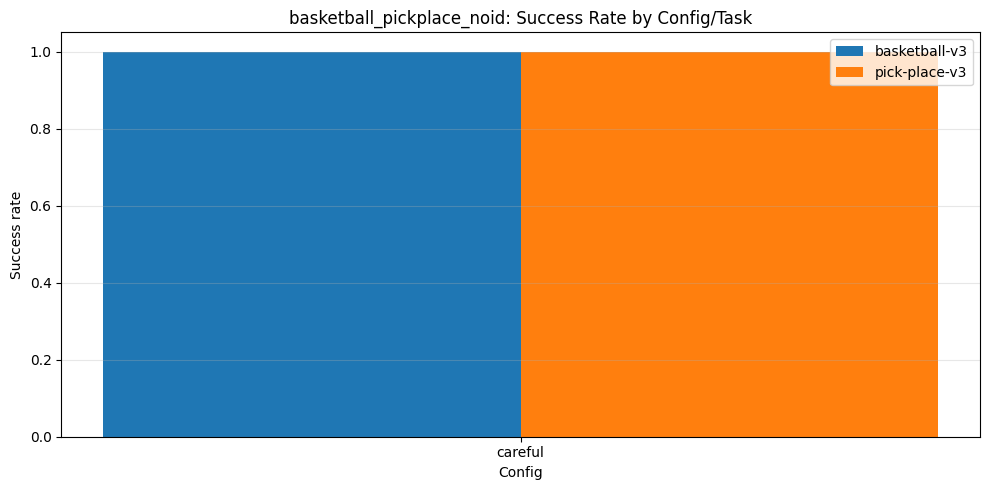

task_name,basketball-v3,push-v3
config,,
base,0.0,1.0


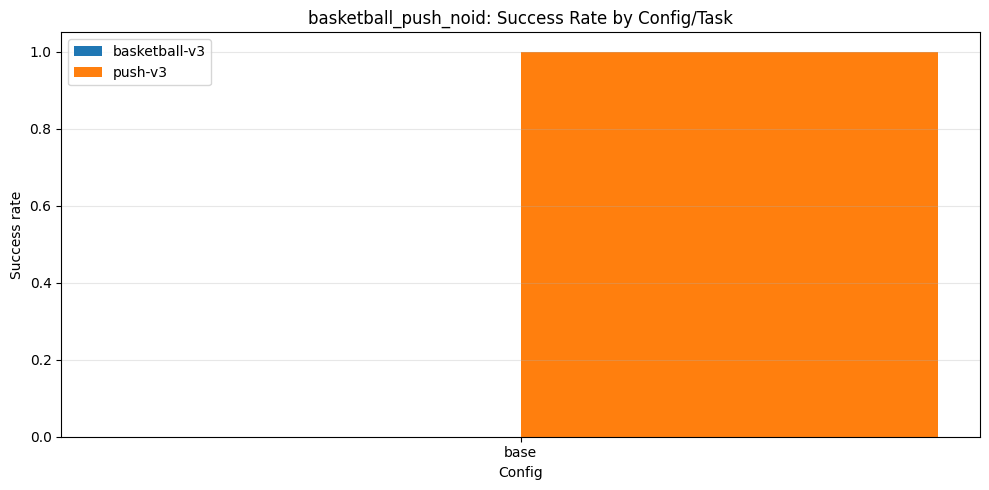

task_name,button-press-v3,push-v3
config,,
careful,1.0,0.026667


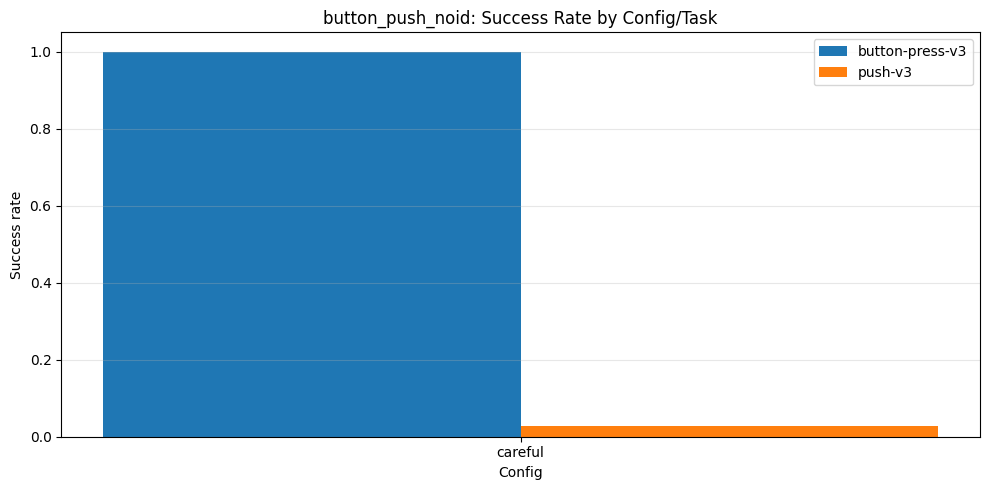

task_name,pick-place-v3,push-v3
config,,
careful,1.0,0.993333


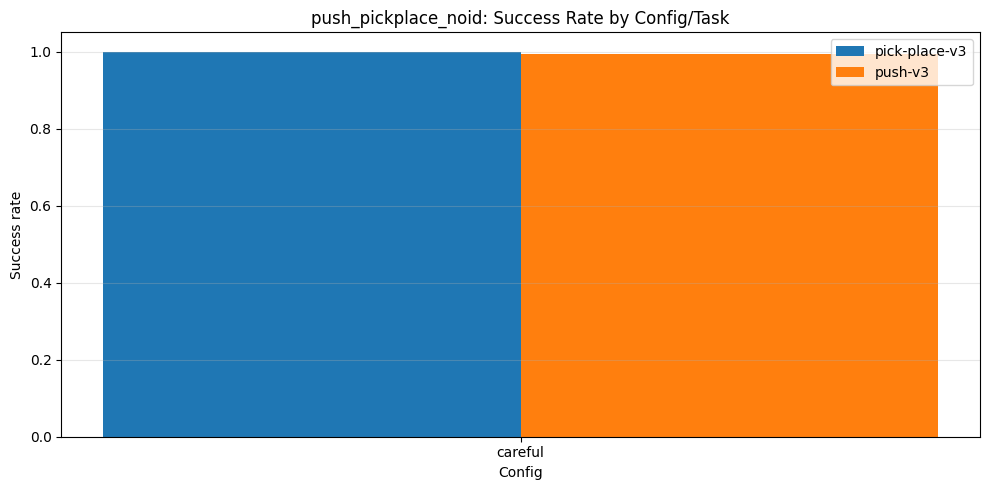

,experiment,config,mean_success,min_success,mean_return,total_episodes
0,basketball_pickplace_noid,careful,1.000000,1.000000,93.475969,600
1,basketball_push_noid,base,0.500000,0.000000,1556.977053,600
2,button_push_noid,careful,0.513333,0.026667,283.305539,600
3,push_pickplace_noid,careful,0.996667,0.993333,111.693803,600


,experiment,config,mean_success,min_success,mean_return,total_episodes
0,basketball_pickplace_noid,careful,1.000000,1.000000,93.475969,600
1,basketball_push_noid,base,0.500000,0.000000,1556.977053,600
2,button_push_noid,careful,0.513333,0.026667,283.305539,600
3,push_pickplace_noid,careful,0.996667,0.993333,111.693803,600


In [3]:

if data.empty:
    print("No compatible summary CSVs found.")
else:
    display(data.sort_values(["experiment", "config", "task_name"]))

    for exp in sorted(data["experiment"].unique()):
        d = data[data["experiment"] == exp]
        pivot = d.pivot_table(index="config", columns="task_name", values="success_rate")
        display(pivot)

        configs = list(pivot.index)
        tasks = list(pivot.columns)
        x = np.arange(len(configs))
        width = 0.8 / max(len(tasks), 1)

        fig, ax = plt.subplots(figsize=(10, 5))
        for i, task in enumerate(tasks):
            ax.bar(x + (i - (len(tasks)-1)/2) * width, pivot[task], width, label=task)
        ax.set_title(f"{exp}: Success Rate by Config/Task")
        ax.set_xlabel("Config")
        ax.set_ylabel("Success rate")
        ax.set_ylim(0, 1.05)
        ax.set_xticks(x)
        ax.set_xticklabels(configs)
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

    ranking = (
        data.groupby(["experiment", "config"])
        .agg(
            mean_success=("success_rate", "mean"),
            min_success=("success_rate", "min"),
            mean_return=("avg_return", "mean") if "avg_return" in data.columns else ("success_rate", "mean"),
            total_episodes=("episodes", "sum") if "episodes" in data.columns else ("success_rate", "count"),
        )
        .reset_index()
        .sort_values(["experiment", "mean_success", "min_success"], ascending=[True, False, False])
    )
    display(ranking)
    display(ranking.groupby("experiment").head(1))


## 3. Save notebook outputs


In [4]:

out_dir = Path("notebook_outputs")
fig_dir = out_dir / "figures"
out_dir.mkdir(exist_ok=True)
fig_dir.mkdir(exist_ok=True)

if not data.empty:
    data.to_csv(out_dir / "loaded_summary_results.csv", index=False)

    for exp in sorted(data["experiment"].unique()):
        d = data[data["experiment"] == exp]
        pivot = d.pivot_table(index="config", columns="task_name", values="success_rate")
        configs = list(pivot.index)
        tasks = list(pivot.columns)
        x = np.arange(len(configs))
        width = 0.8 / max(len(tasks), 1)

        fig, ax = plt.subplots(figsize=(10, 5))
        for i, task in enumerate(tasks):
            ax.bar(x + (i - (len(tasks)-1)/2) * width, pivot[task], width, label=task)
        ax.set_title(f"{exp}: Success Rate by Config/Task")
        ax.set_xlabel("Config")
        ax.set_ylabel("Success rate")
        ax.set_ylim(0, 1.05)
        ax.set_xticks(x)
        ax.set_xticklabels(configs)
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend()
        plt.tight_layout()
        fig.savefig(fig_dir / f"{exp}_success_by_config_task.png", dpi=200, bbox_inches="tight")
        plt.close(fig)

print("Saved outputs to", out_dir)


Saved outputs to notebook_outputs
